# A — Semantic Schema Discovery

**Goal:** Replace Jaccard (exact string matching) with embedding-based cosine similarity to find hidden schema connections.

**Tasks:**
- A.1 — Embed every unique column name
- A.2 — Average column embeddings → one vector per dataset
- A.3 — Rerun independence curve with cosine similarity, compare to 46% Jaccard baseline

## A.1 — Vectorize Column Names

In [2]:
import json
import numpy as np
import pandas as pd
from pathlib import Path
from sentence_transformers import SentenceTransformer

DATA_DIR = Path('../../data')

with open(DATA_DIR / 'nyc_socrata_datasets.json') as f:
    raw = json.load(f)

print(f'Loaded {len(raw):,} datasets')

Loaded 2,394 datasets


In [3]:
# Build a list of column names per dataset
dataset_columns = []
for ds in raw:
    col_details = (ds.get('full_metadata') or {}).get('column_details') or []
    names = [c['name'] for c in col_details if c.get('name')]
    dataset_columns.append({
        'id': ds['id'],
        'name': ds['name'],
        'columns': names
    })

# Unique column names across all datasets
all_names = [name for ds in dataset_columns for name in ds['columns']]
unique_names = list(set(all_names))

print(f'Total column instances:  {len(all_names):,}')
print(f'Unique column names:     {len(unique_names):,}')

Total column instances:  56,184
Unique column names:     24,308


In [4]:
# Inspect the data -- columns only, for a few samples
for ds in raw[:5]:
    col_details = (ds.get('full_metadata') or {}).get('column_details') or []
    col_names = [c['name'] for c in col_details if c.get('name')]
    print(f"{ds['name']}")
    print(f"  {col_names}")
    print()

For Hire Vehicles (FHV) - Active
  ['Active', 'Vehicle License Number', 'Name', 'License Type', 'Expiration Date', 'Permit License Number', 'DMV License Plate Number', 'Vehicle VIN Number', 'Wheelchair Accessible', 'Certification Date', 'Hack Up Date', 'Vehicle Year', 'Base Number', 'Base Name', 'Base Type', 'VEH', 'Base Telephone Number', 'Website', 'Base Address', 'Reason', 'Order Date', 'Last Date Updated', 'Last Time Updated']

Civil Service List (Active)
  ['Exam No', 'List No', 'First Name', 'MI', 'Last Name', 'Adj. FA', 'List Title Code', 'List Title Desc', 'Group No', 'List Agency Code', 'List Agency Desc', 'List Div Code', 'Published Date', 'Established Date', 'Anniversary Date', 'Extension Date', 'Veteran Credit', 'Parent Lgy Credit', 'Sibling Lgy Credit', 'Residency Credit']

DOB Job Application Filings
  ['Job #', 'Doc #', 'Borough', 'House #', 'Street Name', 'Block', 'Lot', 'Bin #', 'Job Type', 'Job Status', 'Job Status Descrp', 'Latest Action Date', 'Building Type', 'Comm

In [5]:
# Embed each unique column name once
# Saves to disk so you don't re-run this every time

EMBEDDINGS_FILE = DATA_DIR / 'column_embeddings.npy'
NAMES_FILE = DATA_DIR / 'column_names.json'

if EMBEDDINGS_FILE.exists():
    print('Loading saved embeddings...')
    embeddings = np.load(EMBEDDINGS_FILE)
    with open(NAMES_FILE) as f:
        saved_names = json.load(f)
else:
    print('Embedding column names (first time only)...')
    model = SentenceTransformer('all-MiniLM-L6-v2')
    embeddings = model.encode(unique_names, show_progress_bar=True, batch_size=256)
    np.save(EMBEDDINGS_FILE, embeddings)
    with open(NAMES_FILE, 'w') as f:
        json.dump(unique_names, f)
    saved_names = unique_names

# name → vector lookup
name_to_vec = {name: embeddings[i] for i, name in enumerate(saved_names)}

print(f'Embeddings shape: {embeddings.shape}')  # (N_unique, 384)

Loading saved embeddings...
Embeddings shape: (24308, 384)


## A.2 — One Vector Per Dataset

Average the column embeddings for each dataset → one vector that represents its schema.

In [6]:
dataset_vectors = []
valid_datasets = []

for ds in dataset_columns:
    vecs = [name_to_vec[col] for col in ds['columns'] if col in name_to_vec]
    if not vecs:
        continue
    dataset_vectors.append(np.mean(vecs, axis=0))
    valid_datasets.append(ds)

dataset_vectors = np.array(dataset_vectors)  # shape: (N_datasets, 384)

print(f'Dataset vectors shape: {dataset_vectors.shape}')

Dataset vectors shape: (2394, 384)


In [7]:
for i in range(5):
    ds = valid_datasets[i]
    print(f"{ds['name']}")
    print(f"  columns: {ds['columns'][:5]}")
    print(f"  vector[:8]: {dataset_vectors[i][:8].round(3)}")
    print()

For Hire Vehicles (FHV) - Active
  columns: ['Active', 'Vehicle License Number', 'Name', 'License Type', 'Expiration Date']
  vector[:8]: [-0.046  0.01  -0.006 -0.016 -0.013  0.003  0.021  0.04 ]

Civil Service List (Active)
  columns: ['Exam No', 'List No', 'First Name', 'MI', 'Last Name']
  vector[:8]: [-0.043  0.018 -0.005  0.009 -0.02   0.025  0.046  0.015]

DOB Job Application Filings
  columns: ['Job #', 'Doc #', 'Borough', 'House #', 'Street Name']
  vector[:8]: [-0.016  0.016 -0.009  0.001 -0.021 -0.018  0.046  0.008]

TLC New Driver Application Status
  columns: ['App No', 'Type', 'App Date', 'Status', 'FRU Interview Scheduled']
  vector[:8]: [-0.026  0.009 -0.013 -0.006 -0.011 -0.003  0.039  0.021]

For Hire Vehicles (FHV) - Active Drivers
  columns: ['License Number', 'Name', 'Type', 'Expiration Date', 'Wheelchair Accessible Trained']
  vector[:8]: [-0.06  -0.012 -0.025  0.015 -0.034  0.001  0.052  0.043]



## A.3 — Semantic Schema Clustering

Compute pairwise cosine similarity between all dataset vectors, then reproduce the independence rate curve.

In [8]:
# Normalize vectors → cosine similarity becomes a dot product
norms = np.linalg.norm(dataset_vectors, axis=1, keepdims=True)
normalized = dataset_vectors / norms

# Full pairwise cosine similarity matrix
sim_matrix = normalized @ normalized.T  # shape: (N, N)

print(f'Similarity matrix shape: {sim_matrix.shape}')
print(f'Value range: [{sim_matrix.min():.3f}, {sim_matrix.max():.3f}]')

Similarity matrix shape: (2394, 2394)
Value range: [-0.139, 1.000]


| Value | Meaning                 |
|-------|-------------------------|
| 1.0   | identical               |
| 0.0   | completely unrelated    |
| -1.0  | opposite meaning        |

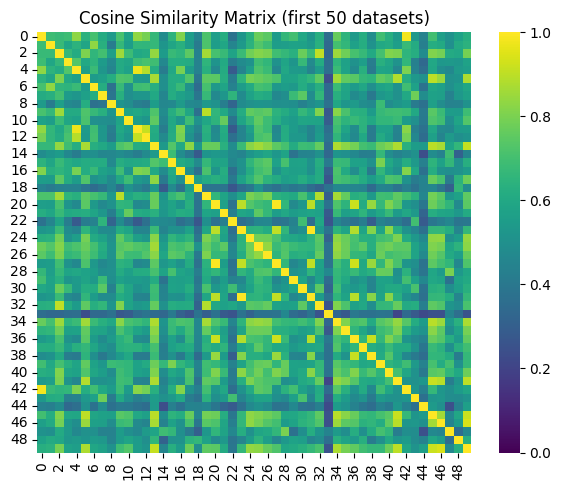

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sample 50 datasets for readability
sample = sim_matrix[:50, :50]

plt.figure(figsize=(6, 5))
sns.heatmap(sample, cmap='viridis', vmin=0, vmax=1)
plt.title('Cosine Similarity Matrix (first 50 datasets)')
plt.tight_layout()
plt.show()

In [10]:
n = len(sim_matrix)
thresholds = np.arange(0.1, 1.01, 0.1)

# For each dataset: what is its highest similarity to any OTHER dataset?
np.fill_diagonal(sim_matrix, 0)
best_match = sim_matrix.max(axis=1)

independence_rates = [(best_match < t).mean() for t in thresholds]

for t, r in zip(thresholds, independence_rates):
    print(f'  threshold {t:.1f}  →  {r:.1%} independent')

  threshold 0.1  →  0.0% independent
  threshold 0.2  →  0.0% independent
  threshold 0.3  →  0.0% independent
  threshold 0.4  →  0.0% independent
  threshold 0.5  →  0.3% independent
  threshold 0.6  →  2.4% independent
  threshold 0.7  →  8.1% independent
  threshold 0.8  →  22.6% independent
  threshold 0.9  →  41.4% independent
  threshold 1.0  →  87.8% independent


### Threshold Ranges and Results:
Does this dataset have at least one other dataset with cosine similarity at or above that threshold?

- **0.1–0.4:** Every single dataset has at least one semantic neighbor.
             At low thresholds, everything is connected to something.

- **0.5–0.6:** Almost everything is still connected. Only 0.3–2.4% are isolated.

- **0.7:** 8.1% isolated — meaning 91.9% of datasets have a semantically similar partner with strong confidence.

- **0.8:** 22.6% isolated — at a high bar, still 77% of datasets find a match.

- **0.9:** 41.4% isolated — very strict threshold, still slightly better than Jaccard's 46%.

- **1.0:** 87.8% isolated — cosine = 1.0 means perfectly identical vectors, which almost never happens.

**Finding:**\
At any reasonable semantic threshold (0.7–0.8), the vast majority of datasets
are connected to at least one other dataset. Jaccard's exact matching was hiding most of
these connections.

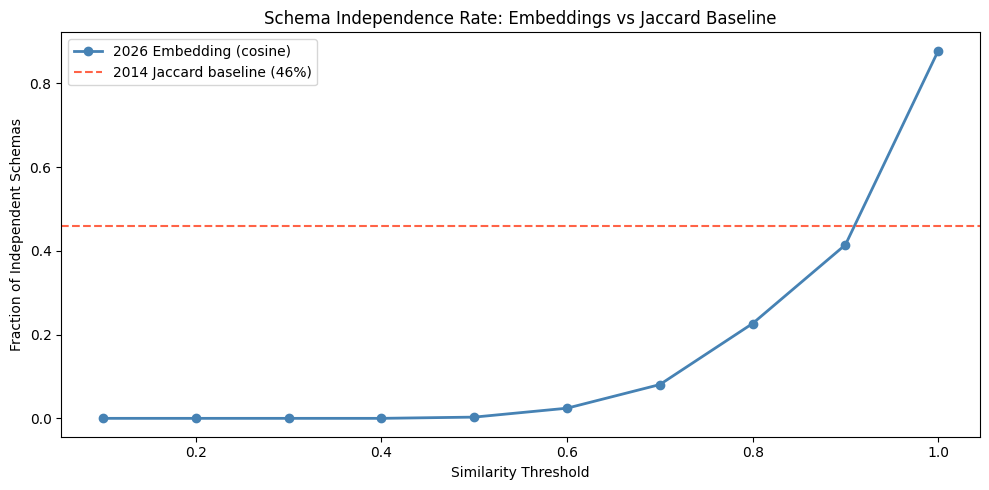

Embedding independence rate at threshold=1.0: 87.8%
Jaccard baseline (2014):                      46.0%
Reduction:                                    -41.8%


In [11]:
plt.figure(figsize=(10, 5))
plt.plot(thresholds, independence_rates, 'o-', color='steelblue', linewidth=2, label='2026 Embedding (cosine)')
plt.axhline(0.46, linestyle='--', color='tomato', linewidth=1.5, label='2014 Jaccard baseline (46%)')
plt.xlabel('Similarity Threshold')
plt.ylabel('Fraction of Independent Schemas')
plt.title('Schema Independence Rate: Embeddings vs Jaccard Baseline')
plt.legend()
plt.tight_layout()
plt.show()

at_1 = independence_rates[-1]
print(f'Embedding independence rate at threshold=1.0: {at_1:.1%}')
print(f'Jaccard baseline (2014):                      46.0%')
print(f'Reduction:                                    {0.46 - at_1:.1%}')

## Output — Save Similarity Matrix for Phase 3

In [12]:
# Save dataset vectors and similarity matrix for Member C / Phase 3
np.save(DATA_DIR / 'dataset_vectors.npy', dataset_vectors)
np.save(DATA_DIR / 'dataset_similarity_matrix.npy', sim_matrix)

# Save dataset ID order so Phase 3 knows which row = which dataset
dataset_ids = [ds['id'] for ds in valid_datasets]
with open(DATA_DIR / 'dataset_ids.json', 'w') as f:
    json.dump(dataset_ids, f)

print(f'Saved:')
print(f'  dataset_vectors.npy          {dataset_vectors.shape}')
print(f'  dataset_similarity_matrix.npy {sim_matrix.shape}')
print(f'  dataset_ids.json              {len(dataset_ids)} datasets')

Saved:
  dataset_vectors.npy          (2394, 384)
  dataset_similarity_matrix.npy (2394, 2394)
  dataset_ids.json              2394 datasets


## Visualization — UMAP

Compress 384 dimensions → 2 so we can plot all datasets and see semantic clusters.

In [13]:
import umap

reducer = umap.UMAP(n_components=2, random_state=42)
coords = reducer.fit_transform(dataset_vectors)

print(f'UMAP output shape: {coords.shape}')  # (2394, 2)

/Users/jinuhyun/Desktop/3001-data-engineering/venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP output shape: (2394, 2)


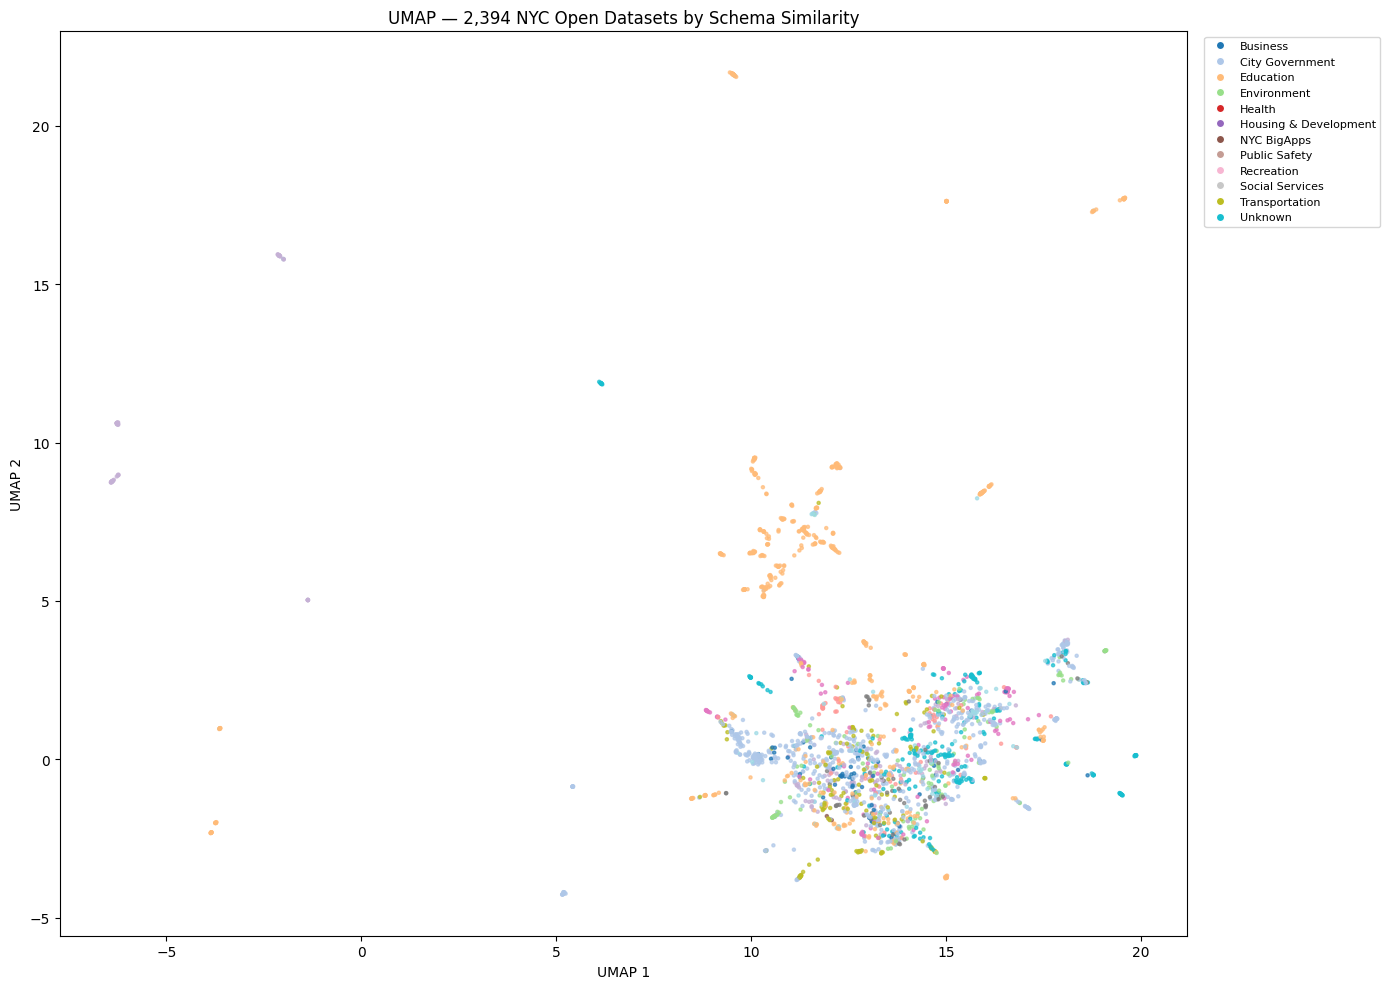

In [14]:
# Color by category
id_to_category = {}
for ds in raw:
    meta = ds.get('full_metadata') or {}
    id_to_category[ds['id']] = meta.get('category') or 'Unknown'

categories = [id_to_category.get(ds['id'], 'Unknown') for ds in valid_datasets]
unique_cats = sorted(set(categories))
cat_to_idx = {c: i for i, c in enumerate(unique_cats)}
color_idx = [cat_to_idx[c] for c in categories]

plt.figure(figsize=(14, 10))
scatter = plt.scatter(coords[:, 0], coords[:, 1], c=color_idx, cmap='tab20', s=5, alpha=0.7)
plt.title('UMAP — 2,394 NYC Open Datasets by Schema Similarity')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')

# Legend
handles = [plt.Line2D([0], [0], marker='o', color='w',
           markerfacecolor=plt.cm.tab20(cat_to_idx[c] / len(unique_cats)),
           markersize=6, label=c) for c in unique_cats]
plt.legend(handles=handles, bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

In [17]:
# Interactive UMAP in the browser
"""
import plotly.express as px
import pandas as pd

umap_df = pd.DataFrame({
    'x': coords[:, 0],
    'y': coords[:, 1],
    'name': [ds['name'] for ds in valid_datasets],
    'category': categories,
})

fig = px.scatter(
    umap_df, x='x', y='y',
    color='category',
    hover_name='name',
    title='UMAP — 2,394 NYC Open Datasets by Schema Similarity',
    labels={'x': 'UMAP 1', 'y': 'UMAP 2'},
    opacity=0.7,
    width=1000, height=700,
)
fig.update_traces(marker=dict(size=5))
fig.show(renderer="browser")
"""

'\nimport plotly.express as px\nimport pandas as pd\n\numap_df = pd.DataFrame({\n    \'x\': coords[:, 0],\n    \'y\': coords[:, 1],\n    \'name\': [ds[\'name\'] for ds in valid_datasets],\n    \'category\': categories,\n})\n\nfig = px.scatter(\n    umap_df, x=\'x\', y=\'y\',\n    color=\'category\',\n    hover_name=\'name\',\n    title=\'UMAP — 2,394 NYC Open Datasets by Schema Similarity\',\n    labels={\'x\': \'UMAP 1\', \'y\': \'UMAP 2\'},\n    opacity=0.7,\n    width=1000, height=700,\n)\nfig.update_traces(marker=dict(size=5))\nfig.show(renderer="browser")\n'

## Threshold Analysis

What fraction of pairs exceed each similarity threshold? Used to pick a meaningful cutoff.

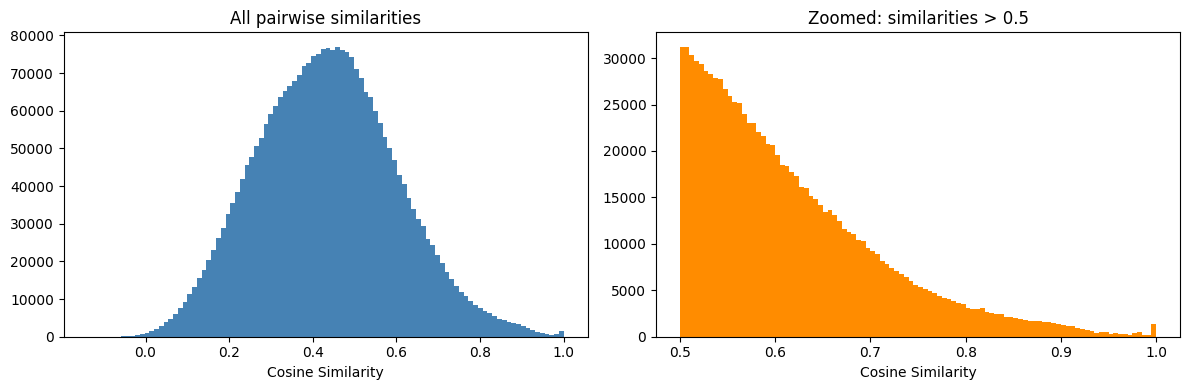

> 0.70: 6.0% of pairs
> 0.75: 3.5% of pairs
> 0.80: 1.9% of pairs
> 0.85: 1.0% of pairs
> 0.90: 0.4% of pairs


In [18]:
upper = sim_matrix[np.triu_indices(len(sim_matrix), k=1)]

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(upper, bins=100, color='steelblue', edgecolor='none')
plt.title('All pairwise similarities')
plt.xlabel('Cosine Similarity')

plt.subplot(1, 2, 2)
plt.hist(upper[upper > 0.5], bins=100, color='darkorange', edgecolor='none')
plt.title('Zoomed: similarities > 0.5')
plt.xlabel('Cosine Similarity')

plt.tight_layout()
plt.show()

print(f'> 0.70: {(upper > 0.70).mean():.1%} of pairs')
print(f'> 0.75: {(upper > 0.75).mean():.1%} of pairs')
print(f'> 0.80: {(upper > 0.80).mean():.1%} of pairs')
print(f'> 0.85: {(upper > 0.85).mean():.1%} of pairs')
print(f'> 0.90: {(upper > 0.90).mean():.1%} of pairs')


## Joinability Pairs Output

In [ ]:
THRESHOLD = 0.75

rows = []
n = len(valid_datasets)
for i in range(n):
    for j in range(i + 1, n):
        score = sim_matrix[i, j]
        if score >= THRESHOLD:
            rows.append({
                'dataset_id_1': valid_datasets[i]['id'],
                'column_name_1': None,
                'dataset_id_2': valid_datasets[j]['id'],
                'column_name_2': None,
                'score': round(float(score), 4),
                'method': 'embedding',
            })

df_pairs = pd.DataFrame(rows)
# df_pairs.to_parquet(DATA_DIR / 'joinability_pairs_embedding.parquet', index=False)
df_pairs.to_csv(DATA_DIR / 'joinability_pairs_embedding.csv', index=False)

print(f'{len(df_pairs):,} pairs saved at threshold {THRESHOLD}')
df_pairs.head()

ArrowKeyError: A type extension with name pandas.period already defined